In [1]:
%matplotlib widget

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [2]:
DATA_PATH = 'data/seoul_temperature_daily.csv'
temp_data = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
temp = temp_data["tavg"].values

In [3]:
def indexing(x, arr):
    n = len(x)
    if n==1:
        arr.append(x[0])
        return
    
    even = []
    odd = []
    for i in range(n):
        if i % 2 == 0:
            even.append(x[i])
        else:
            odd.append(x[i])
    indexing(even, arr)
    indexing(odd, arr)

In [4]:
PI = np.arccos(-1)
print(PI)

3.141592653589793


In [5]:
def reorder(x):
    order = [0]
    n = len(x)
    for i in range(1,n//2):
        order.extend([-i,i])
    order.append(n//2)

    reordered = x[[m%n for m in order]]
    return reordered

In [6]:
t = np.array([1,2,3,4,5])
n = 8
t = np.concat([t, np.zeros((n-len(t)-1))])
print(t)

[1. 2. 3. 4. 5. 0. 0.]


In [7]:
def fft(x, invert = False):
    l = len(x)
    N = 1
    n_list = [1]
    while N<l:
        N<<=1
        if N<l:
            n_list.append(N)
    x = np.concat([x, np.zeros(N-len(x))])
    temp_x = np.arange(N)
    arr = []
    indexing(temp_x, arr)
    init_index = np.array(arr)
    #print(f"init index : {init_index}")
    prev_result = np.zeros(N,dtype=np.complex128)
    curr_result = np.zeros(N,dtype=np.complex128)
    X = np.zeros(N)
    
    #print(f"N : {N}, nlist : {n_list} ")

    for n in n_list:
        if n == 1 :
            for i in range(N//2):
                even_idx = i*2
                odd_idx = even_idx+1
                even = init_index[even_idx]
                odd = init_index[odd_idx]

                curr_result[even_idx] = x[even] + x[odd]
                curr_result[odd_idx] = x[even] - x[odd]

            prev_result, curr_result = curr_result, prev_result
            #print(f"prev_result : {prev_result}")
        else:
            idx = 0
            w_ = np.exp(-1j*2.0*PI/ (n*2.0)) if invert else np.exp(1j*2.0*PI/ (n*2.0))

            for i in range((N//2)//n):
                w = 1
                for j in range(n):
                    even_idx = idx
                    odd_idx = idx+n
                    even = prev_result[even_idx]
                    t = prev_result[odd_idx] * w
                    curr_result[even_idx]  = even + t
                    curr_result[odd_idx]  = even - t
                    idx+=1
                    w*=w_

                idx+=n
            prev_result, curr_result = curr_result, prev_result
    
    return prev_result

In [8]:
temp_1024 = temp[:1024]
x_ret = fft(temp_1024)

l = [1,2,3]
final_fft = np.zeros_like(x_ret)
final_fft[0] = x_ret[0]
for i in l:
    final_fft[i] = x_ret[i]
    final_fft[-i] = x_ret[-i]

ret2 = fft(final_fft, True)
ret2 = ret2 / len(ret2)

c:\Users\son97\gaussian_splatting\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\son97\gaussian_splatting\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


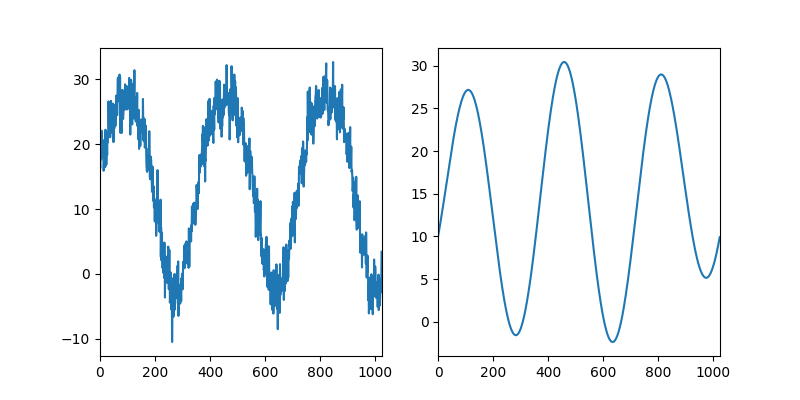

In [9]:
total_day = len(temp_1024) 
fig, ax = plt.subplots(1,2,figsize=(8,4))
ax_x = np.arange(total_day)
ax[0].plot(ax_x, temp_1024)
ax[0].set_xlim([0,total_day])
ax[1].plot(ax_x, ret2[:total_day])
ax[1].set_xlim([0,total_day])

plt.show()

In [ ]:
def get_filtered_fft(fft_ret, n):
    
    ret_filtered = np.zeros_like(fft_ret)
    keep = [0]
    for i in range(1,n+1):
        keep.extend([i,-i])

    for k in keep:
        ret_filtered[k] = fft_ret[k]

    fin_ret = np.fft.ifft(ret_filtered)
    return fin_ret

In [ ]:
fft_ret = np.fft.fft(temp)
init_n = 3
fin_ret = get_filtered_fft(fft_ret, init_n)

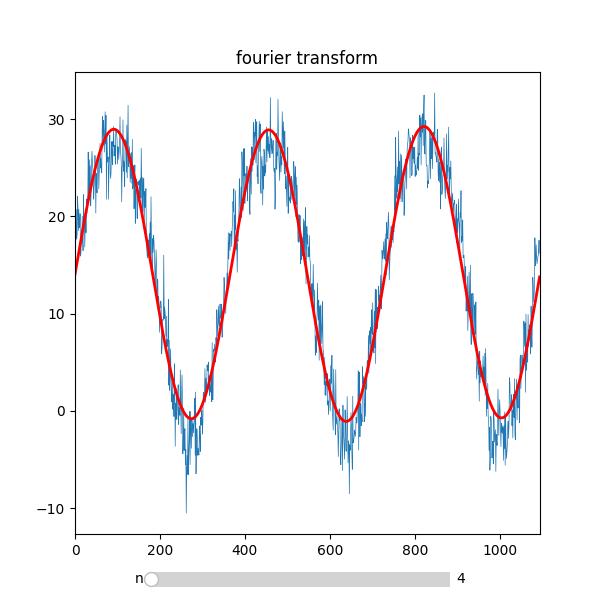

In [13]:
total_day = len(fin_ret) 

fig, ax = plt.subplots(1,1,figsize=(6,6))
ax_x = np.arange(total_day)
ax.set_xlim([0,total_day])
ax.set_title("fourier transform")
ax.plot(ax_x, temp, linewidth=0.5)
fft_plot, = ax.plot(ax_x, fin_ret, color='r', linewidth=2)
ax_slider = plt.axes([0.25, 0.01, 0.5, 0.05])
slider = Slider(ax_slider,label="n", valinit = init_n, valmin=1,valmax=1095)

def update(x):
    n = int(slider.val)
    ret = get_filtered_fft(fft_ret, n)
    fft_plot.set_ydata(ret)

    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()